# 01 · Preprocessing

**Threshold-crossing RUL prediction for lithium-ion batteries — DLinear and NLinear versus tree-based models**

This notebook turns the raw NASA PCoE `.mat` files and CALCE CX2 Arbin `.xlsx` exports into one clean
capacity-per-cycle table per cell, with end-of-life (EOL) and remaining-useful-life (RUL) labels.
Every later notebook reads its output.

| | |
|---|---|
| **Inputs** | `data/NASA_PCoE/*.mat`, `data/CALCE_CX2/CX2_*/*.xlsx` (path set by `BATTERY_RUL_DATA`) |
| **Outputs** | `processed/cells/<CELL>.parquet`, `processed/cell_summary.csv`, `processed/drop_report.csv`, `figures/01_*.png` |
| **Feeds** | 02 (EDA), 03 (features), and through them every research question |

### Four decisions that determine validity

1. **CALCE capacity is measured per discharge segment.** `Discharge_Capacity(Ah)` accumulates within each Arbin
   file, so grouping by `Cycle_Index` returns running totals (up to 140 Ah for a 1.35 Ah cell). The loader measures
   the capacity gained across each contiguous run of discharging rows instead.
2. **Two series from one raw signal.** `capacity_input` uses a *trailing* Hampel filter, so the value at cycle *t*
   depends only on cycles ≤ *t*; it is the only series a model ever sees. `capacity_label` uses a *centred* filter and
   smoothing and is used only to decide when a cell truly reached end of life.
3. **End of life needs a sustained crossing.** EOL is the first cycle at which the smoothed capacity stays at or
   below 80% of the reference for five consecutive cycles, so a single noisy dip is not mistaken for failure.
4. **Two EOL conventions.** 80% of *rated* capacity (primary, comparable with the literature) and 80% of each cell's
   *initial* capacity (sensitivity check).

Test targets are never altered beyond the causal cleaning in point 2.

In [1]:
# Make the repository importable, locally or on Google Colab.
import os
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    # Once per session:
    #   !git clone https://github.com/<your-account>/battery-rul-linear.git /content/battery-rul-linear
    #   %pip install -q -r /content/battery-rul-linear/requirements.txt
    # Raw data on Drive: MyDrive/battery_rul/data/NASA_PCoE/*.mat and .../CALCE_CX2/CX2_*/
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/battery-rul-linear")
    os.environ.setdefault("BATTERY_RUL_DATA", "/content/drive/MyDrive/battery_rul/data")

ROOT = Path.cwd().resolve()
if not (ROOT / "battery_rul").is_dir():
    ROOT = ROOT.parent                          # launched from notebooks/
os.environ.setdefault("BATTERY_RUL_ROOT", str(ROOT))
sys.path.insert(0, str(ROOT))

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from battery_rul import config
from battery_rul.data import discover
from battery_rul.dataset import load_cells
from battery_rul.plotting import INK, INK_2, MUTED, savefig, setup_style
from battery_rul.preprocess import run_preprocessing
from battery_rul.utils import ensure_dirs, markdown_table, record_run

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
setup_style()
ensure_dirs()
run_info = record_run("01_preprocessing")
print("data folder   :", config.DATA_DIR)
print("study groups  :", config.STUDY_GROUPS)
print("EOL rule      :", f"{config.LABELS.eol_frac:.0%} of reference, sustained {config.LABELS.eol_persist} cycles")

data folder   : D:\AIO2026\module_4_research\rul_prediction_research\data
study groups  : ('nasa_core', 'calce_cc')
EOL rule      : 80% of reference, sustained 5 cycles


## 1. What is in the data folder

Every `.mat` file and every `CX2_*` / `CS2_*` folder is discovered and matched against the cell groups declared in
`battery_rul/config.py`. Cells outside those groups (for example NASA's second campaign, B0025 onwards, which uses
different load profiles and reference conditions) are listed, not silently ignored.

In [3]:
found = discover(config.DATA_DIR)
inventory = pd.DataFrame([
    {"cell": name, "kind": kind, "group": config.group_of(name) or "-",
     "in_study": config.group_of(name) in config.STUDY_GROUPS}
    for name, (kind, _) in sorted(found.items())
])
print(f"{len(inventory)} cells found, {inventory['in_study'].sum()} in the study groups")
inventory.groupby(["kind", "group", "in_study"]).size().rename("cells").reset_index()

44 cells found, 11 in the study groups


,kind,group,in_study,cells
0,calce,calce_cc,True,7
1,calce,calce_varied,False,3
2,nasa,-,False,30
3,nasa,nasa_core,True,4


In [4]:
missing = sorted({c for g in config.STUDY_GROUPS for c in config.CELL_GROUPS[g]} - set(found))
print("configured study cells not present in the data folder:", missing or "none")

configured study cells not present in the data folder: ['CX2_31']


## 2. Load, clean and label

`FORCE_RELOAD = False` reuses the per-cell parquet cache in `processed/raw_cycles/`; reading every CALCE workbook
takes minutes the first time. Set it to `True` after changing the loader.

In [5]:
FORCE_RELOAD = False
summary, drop_report, skipped = run_preprocessing(config.DATA_DIR, force=FORCE_RELOAD,
                                                  log=lambda m: print(m) if not m.startswith("      ") else None)

B0005 (nasa)
  168 cycles | initial 1.835 Ah | EOL rated 74 | EOL initial 107 | outliers 0 | regeneration 7
B0006 (nasa)
  168 cycles | initial 2.019 Ah | EOL rated 63 | EOL initial 62 | outliers 3 | regeneration 11
B0007 (nasa)
  168 cycles | initial 1.881 Ah | EOL rated 94 | EOL initial 125 | outliers 6 | regeneration 7
B0018 (nasa)
  132 cycles | initial 1.839 Ah | EOL rated 60 | EOL initial 78 | outliers 0 | regeneration 9
CX2_16 (calce)
  2007 cycles | initial 1.269 Ah | EOL rated 1000 | EOL initial 1117 | outliers 109 | regeneration 167
CX2_3 (calce)
  1535 cycles | initial 1.393 Ah | EOL rated 916 | EOL initial 807 | outliers 52 | regeneration 47
CX2_32 (calce)
  ! skipped: only 9 usable cycles of 3330
CX2_33 (calce)
  1688 cycles | initial 1.293 Ah | EOL rated 621 | EOL initial 823 | outliers 107 | regeneration 69
CX2_34 (calce)
  1727 cycles | initial 1.352 Ah | EOL rated 661 | EOL initial 659 | outliers 109 | regeneration 43
CX2_35 (calce)
  1804 cycles | initial 1.364 Ah | E

In [6]:
print("Skipped cells:")
for name, reason in skipped:
    print(f"  {name:8s} {reason}")

Skipped cells:
  B0025    not in the configured cell groups
  B0026    not in the configured cell groups
  B0027    not in the configured cell groups
  B0028    not in the configured cell groups
  B0029    not in the configured cell groups
  B0030    not in the configured cell groups
  B0031    not in the configured cell groups
  B0032    not in the configured cell groups
  B0033    not in the configured cell groups
  B0034    not in the configured cell groups
  B0036    not in the configured cell groups
  B0038    not in the configured cell groups
  B0039    not in the configured cell groups
  B0040    not in the configured cell groups
  B0041    not in the configured cell groups
  B0042    not in the configured cell groups
  B0043    not in the configured cell groups
  B0044    not in the configured cell groups
  B0045    not in the configured cell groups
  B0046    not in the configured cell groups
  B0047    not in the configured cell groups
  B0048    not in the configured cell gr

## 3. Cell summary

One row per processed cell. `eol_rated` / `eol_initial` are the true end-of-life cycles under each convention;
`eol_*_first_dip` is where a naive single-crossing rule would have put it.

In [7]:
cols = ["cell", "dataset", "group", "n_cycles", "initial_Ah", "initial_over_rated", "final_Ah",
        "eol_rated", "eol_initial", "n_outliers_causal", "n_regeneration", "regen_per_100_cycles",
        "fade_rate_mAh_per_cycle"]
summary[cols]

,cell,dataset,group,n_cycles,initial_Ah,initial_over_rated,final_Ah,eol_rated,eol_initial,n_outliers_causal,n_regeneration,regen_per_100_cycles,fade_rate_mAh_per_cycle
0,B0005,NASA,nasa_core,168,1.8352,0.9176,1.3251,74,107,0,7,4.167,3.1909
1,B0006,NASA,nasa_core,168,2.0191,1.0095,1.1857,63,62,3,11,6.548,6.7090
2,B0007,NASA,nasa_core,168,1.8806,0.9403,1.4325,94,125,6,7,4.167,3.0024
3,B0018,NASA,nasa_core,132,1.8388,0.9194,1.3411,60,78,0,9,6.818,4.1919
4,CX2_16,CALCE,calce_cc,2007,1.2691,0.9401,0.8281,1000,1117,109,167,8.321,0.1925
5,CX2_3,CALCE,calce_varied,1535,1.3927,1.0316,0.3345,916,807,52,47,3.062,0.3429
6,CX2_33,CALCE,calce_cc,1688,1.2933,0.9580,0.5600,621,823,107,69,4.088,0.3435
7,CX2_34,CALCE,calce_cc,1727,1.3519,1.0014,0.6245,661,659,109,43,2.490,0.4127
8,CX2_35,CALCE,calce_cc,1804,1.3636,1.0101,0.5556,836,790,148,45,2.494,0.3406
9,CX2_36,CALCE,calce_cc,1961,1.3581,1.0060,0.5414,687,653,146,80,4.080,0.4076


In [8]:
study = summary[summary["group"].isin(config.STUDY_GROUPS)].copy()
print(markdown_table(study[["cell", "dataset", "n_cycles", "initial_Ah", "eol_rated", "eol_initial",
                            "regen_per_100_cycles"]], floatfmt=".3f"))

| cell   | dataset   |   n_cycles |   initial_Ah |   eol_rated |   eol_initial |   regen_per_100_cycles |
|:-------|:----------|-----------:|-------------:|------------:|--------------:|-----------------------:|
| B0005  | NASA      |        168 |        1.835 |          74 |           107 |                  4.167 |
| B0006  | NASA      |        168 |        2.019 |          63 |            62 |                  6.548 |
| B0007  | NASA      |        168 |        1.881 |          94 |           125 |                  4.167 |
| B0018  | NASA      |        132 |        1.839 |          60 |            78 |                  6.818 |
| CX2_16 | CALCE     |       2007 |        1.269 |        1000 |          1117 |                  8.321 |
| CX2_33 | CALCE     |       1688 |        1.293 |         621 |           823 |                  4.088 |
| CX2_34 | CALCE     |       1727 |        1.352 |         661 |           659 |                  2.490 |
| CX2_35 | CALCE     |       1804 |        1.3

## 4. What cleaning removed

Cycles outside 5–125% of rated capacity are dropped as aborted tests or logging glitches. A low kept fraction points
to a loader problem, not a data property — this check is what exposed the CALCE running-total issue.

In [9]:
drops = drop_report.copy()
drops["kept_frac"] = drops["n_kept"] / drops["n_read"].clip(lower=1)
flagged = drops[drops["kept_frac"] < 0.9]
print(f"cells keeping < 90% of cycles: {len(flagged)}")
drops[["cell", "n_read", "n_kept", "kept_frac", "n_nan", "n_below_min", "n_above_max", "raw_min_Ah", "raw_max_Ah"]]

cells keeping < 90% of cycles: 2


,cell,n_read,n_kept,kept_frac,n_nan,n_below_min,n_above_max,raw_min_Ah,raw_max_Ah
0,B0005,168,168,1.000000,0,0,0,1.287453,1.856487
1,B0006,168,168,1.000000,0,0,0,1.153818,2.035338
2,B0007,168,168,1.000000,0,0,0,1.400455,1.891052
3,B0018,132,132,1.000000,0,0,0,1.341051,1.855005
4,CX2_16,2008,2007,0.999502,0,0,1,0.090014,12.497349
5,CX2_3,3377,1535,0.454545,0,1842,0,0.020004,1.419368
6,CX2_32,3330,9,0.002703,0,3321,0,0.022042,1.357700
7,CX2_33,1688,1688,1.000000,0,0,0,0.140567,1.296006
8,CX2_34,1727,1727,1.000000,0,0,0,0.461390,1.354935
9,CX2_35,1805,1804,0.999446,0,1,0,0.061899,1.365960


## 5. Validation checks

These must all pass before any modelling. They are assertions, so a failure stops the notebook.

In [10]:
cells = load_cells(groups=tuple(summary["group"].dropna().unique()))
checks = []
for name, cell in cells.items():
    rated = cell.references["rated"]
    checks += [
        (name, "capacity within 5-125% of rated", bool(np.all((cell.capacity > 0.05 * rated) &
                                                             (cell.capacity < 1.25 * rated)))),
        (name, "no running totals (max <= 1.25 x rated)", bool(cell.capacity.max() <= 1.25 * rated)),
        (name, "at least 20 cycles", cell.n_cycles >= 20),
        (name, "finite values", bool(np.isfinite(cell.capacity).all() and np.isfinite(cell.label).all())),
    ]
check_df = pd.DataFrame(checks, columns=["cell", "check", "passed"])
print(check_df.groupby("check")["passed"].agg(["sum", "count"]))
assert check_df["passed"].all(), check_df[~check_df["passed"]]

study_cells = [c for c in cells.values() if c.group in config.STUDY_GROUPS]
no_eol = [c.name for c in study_cells if not c.reaches_eol("rated")]
print("study cells that never reach 80% of rated capacity (trained on, never tested):", no_eol or "none")

                                         sum  count
check                                              
at least 20 cycles                        13     13
capacity within 5-125% of rated           13     13
finite values                             13     13
no running totals (max <= 1.25 x rated)   13     13
study cells that never reach 80% of rated capacity (trained on, never tested): none


## 6. The sustained-crossing rule in practice

Where the naive first-dip rule and the sustained rule disagree, the naive rule would have produced a false early
failure and a wrong RUL label for every cycle before it.

In [11]:
rule = study[["cell", "eol_rated", "eol_rated_first_dip", "eol_initial", "eol_initial_first_dip"]].copy()
rule["rated_gap_cycles"] = rule["eol_rated"] - rule["eol_rated_first_dip"]
rule["initial_gap_cycles"] = rule["eol_initial"] - rule["eol_initial_first_dip"]
print(f"cells where the rules disagree (rated): {(rule['rated_gap_cycles'].fillna(0) != 0).sum()} of {len(rule)}")
rule

cells where the rules disagree (rated): 3 of 11


,cell,eol_rated,eol_rated_first_dip,eol_initial,eol_initial_first_dip,rated_gap_cycles,initial_gap_cycles
0,B0005,74,74,107,107,0,0
1,B0006,63,63,62,62,0,0
2,B0007,94,86,125,125,8,0
3,B0018,60,60,78,78,0,0
4,CX2_16,1000,1000,1117,1117,0,0
6,CX2_33,621,621,823,823,0,0
7,CX2_34,661,661,659,659,0,0
8,CX2_35,836,836,790,790,0,0
9,CX2_36,687,656,653,649,31,4
10,CX2_37,760,760,687,687,0,0


## 7. Cleaning, illustrated

Raw capacity, the causal input series and the centred label series for one NASA and one CALCE cell. Outliers
flagged by the causal filter are marked.

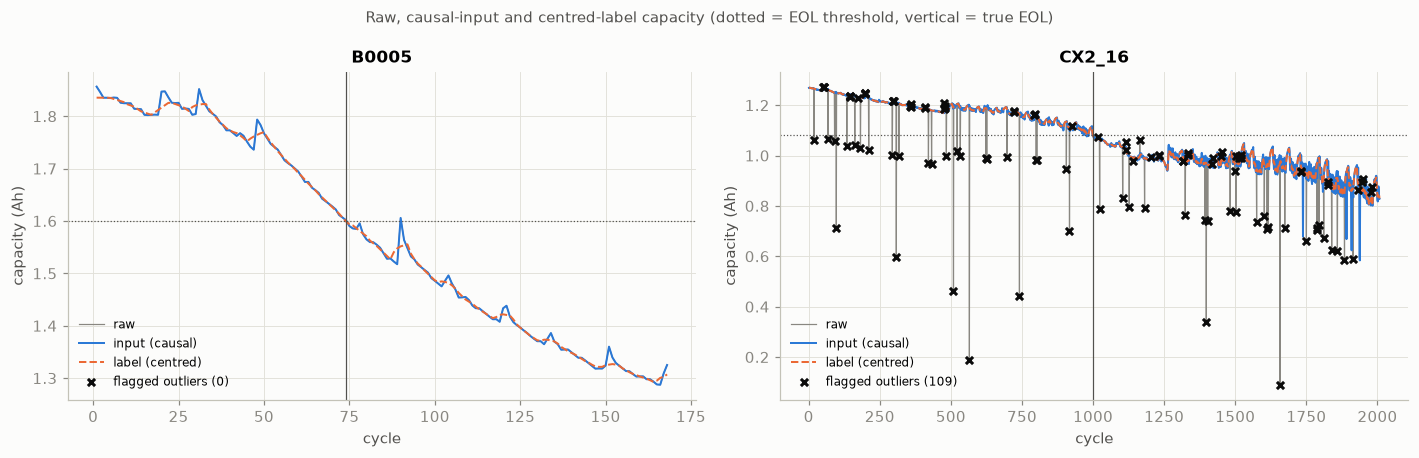

In [12]:
def cleaning_panel(ax, name):
    df = pd.read_parquet(config.PROCESSED_DIR / "cells" / f"{name}.parquet")
    ax.plot(df["cycle"], df["capacity_raw"], color=MUTED, lw=0.8, label="raw")
    ax.plot(df["cycle"], df["capacity_input"], color="#2a78d6", lw=1.3, label="input (causal)")
    ax.plot(df["cycle"], df["capacity_label"], color="#eb6834", lw=1.3, ls="--", label="label (centred)")
    out = df[df["is_outlier_causal"]]
    ax.scatter(out["cycle"], out["capacity_raw"], marker="x", s=22, color=INK, zorder=4,
               label=f"flagged outliers ({len(out)})")
    info = summary.set_index("cell").loc[name]
    ax.axhline(info["threshold_rated_Ah"], color=INK_2, lw=0.8, ls=":")
    if pd.notna(info["eol_rated"]):
        ax.axvline(info["eol_rated"], color=INK_2, lw=0.8)
    ax.set(title=f"{name}", xlabel="cycle", ylabel="capacity (Ah)")
    ax.legend(fontsize=8, loc="lower left")

examples = [n for n in (study[study["dataset"] == "NASA"]["cell"].head(1).tolist() +
                        study[study["dataset"] == "CALCE"]["cell"].head(1).tolist())]
fig, axes = plt.subplots(1, len(examples), figsize=(6.5 * len(examples), 4.2), squeeze=False)
for ax, name in zip(axes[0], examples):
    cleaning_panel(ax, name)
fig.suptitle("Raw, causal-input and centred-label capacity (dotted = EOL threshold, vertical = true EOL)",
             fontsize=10, color=INK_2)
fig.tight_layout()
savefig(fig, "01_cleaning_examples")
plt.show()

## 8. Summary

The printout below is generated from the tables above, so it cannot drift from the data.

In [13]:
for ds, g in study.groupby("dataset"):
    print(f"{ds}: {len(g)} cells, {g['n_cycles'].min()}-{g['n_cycles'].max()} cycles, "
          f"initial capacity {g['initial_Ah'].min():.3f}-{g['initial_Ah'].max():.3f} Ah, "
          f"EOL (rated) cycle {g['eol_rated'].min():.0f}-{g['eol_rated'].max():.0f}, "
          f"{int(g['eol_rated'].notna().sum())} cells reach EOL")
print(f"\nskipped cells: {len(skipped)} | flagged low-keep cells: {len(flagged)} | validation checks passed: "
      f"{int(check_df['passed'].sum())}/{len(check_df)}")
print("next: 02_EDA.ipynb")

CALCE: 7 cells, 1274-2007 cycles, initial capacity 1.269-1.364 Ah, EOL (rated) cycle 621-1000, 7 cells reach EOL
NASA: 4 cells, 132-168 cycles, initial capacity 1.835-2.019 Ah, EOL (rated) cycle 60-94, 4 cells reach EOL

skipped cells: 31 | flagged low-keep cells: 2 | validation checks passed: 52/52
next: 02_EDA.ipynb
